In [1]:
import pandas as pd
import numpy as np
import sqlite3
import yfinance as yf
from scipy.stats import linregress
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

warnings.filterwarnings('ignore')

# Create directory for exported data
os.makedirs('../reports/data', exist_ok=True)

# Connect to database
conn = sqlite3.connect('../bluestock_mf.db')

# Fetch NAV and Fund Master data
query = """
SELECT n.date, n.amfi_code, n.nav, f.scheme_name, f.expense_ratio_pct 
FROM nav_history n
JOIN fund_master f ON n.amfi_code = f.amfi_code
ORDER BY n.amfi_code, n.date
"""
df = pd.read_sql(query, conn, parse_dates=['date'])

# Pivot NAV data: Dates as index, Schemes as columns
nav_pivot = df.pivot(index='date', columns='scheme_name', values='nav').dropna(axis=1, how='all')

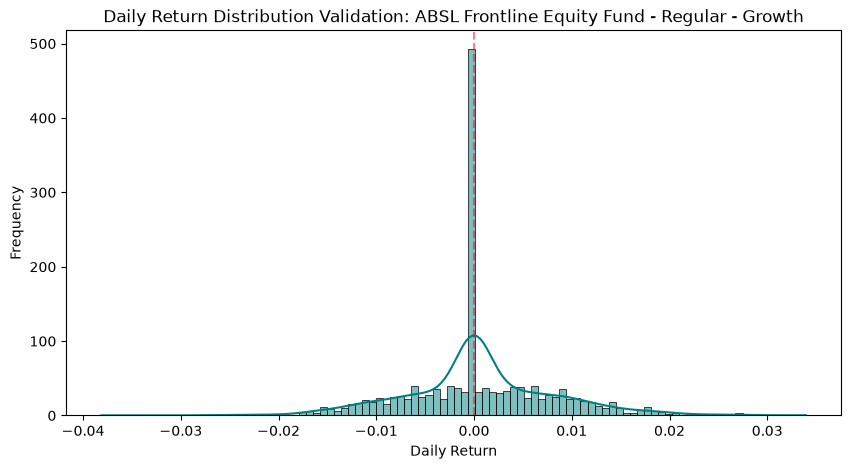

In [2]:
# Compute daily returns: (nav_t / nav_t-1) - 1
daily_returns = nav_pivot.pct_change().dropna()

# Validate distribution for a sample fund
sample_fund = daily_returns.columns[0]
plt.figure(figsize=(10, 5))
sns.histplot(daily_returns[sample_fund], bins=100, kde=True, color='teal')
plt.title(f'Daily Return Distribution Validation: {sample_fund}')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.axvline(0, color='red', linestyle='--', alpha=0.5)
plt.show()

In [3]:
def calculate_cagr(series, periods=252):
    if len(series.dropna()) == 0: return np.nan
    start_val = series.dropna().iloc[0]
    end_val = series.dropna().iloc[-1]
    years = len(series.dropna()) / periods
    return (end_val / start_val) ** (1 / years) - 1 if years > 0 else np.nan

# Define timeframes based on trading days (~252 days/year)
cagr_results = []
for fund in nav_pivot.columns:
    fund_nav = nav_pivot[fund].dropna()
    cagr_1y = calculate_cagr(fund_nav.iloc[-252:]) if len(fund_nav) >= 252 else np.nan
    cagr_3y = calculate_cagr(fund_nav.iloc[-252*3:]) if len(fund_nav) >= 252*3 else np.nan
    cagr_5y = calculate_cagr(fund_nav.iloc[-252*5:]) if len(fund_nav) >= 252*5 else np.nan
    
    cagr_results.append({
        'scheme_name': fund,
        'CAGR_1yr': cagr_1y,
        'CAGR_3yr': cagr_3y,
        'CAGR_5yr': cagr_5y
    })

df_metrics = pd.DataFrame(cagr_results).set_index('scheme_name')
display(df_metrics.head())

,CAGR_1yr,CAGR_3yr,CAGR_5yr
scheme_name,,,
ABSL Frontline Equity Fund - Regular - Growth,0.375166,0.223977,0.174277
ABSL Liquid Fund - Regular - Growth,0.051329,0.043414,0.043191
ABSL Small Cap Fund - Regular - Growth,-0.091959,-0.055736,0.013231
Axis Bluechip Fund - Direct - Growth,0.113981,0.089343,0.107085
Axis Bluechip Fund - Regular - Growth,0.047122,0.000517,0.018574


In [4]:
risk_free_rate = 0.065 # RBI repo rate proxy
daily_rf = risk_free_rate / 252

ratios = []
for fund in daily_returns.columns:
    ret = daily_returns[fund]
    excess_ret = ret - daily_rf
    
    # Sharpe Ratio
    sharpe = (excess_ret.mean() / ret.std()) * np.sqrt(252)
    
    # Sortino Ratio (Downside deviation only)
    downside_ret = excess_ret[excess_ret < 0]
    sortino = (excess_ret.mean() / downside_ret.std()) * np.sqrt(252) if len(downside_ret) > 0 else np.nan
    
    ratios.append({'scheme_name': fund, 'Sharpe_Ratio': sharpe, 'Sortino_Ratio': sortino})

df_metrics = df_metrics.join(pd.DataFrame(ratios).set_index('scheme_name'))

In [6]:
# Fetch Nifty 100 benchmark data using yfinance
nifty100 = yf.download('^CNX100', start=nav_pivot.index.min(), end=nav_pivot.index.max(), progress=False)['Close']
nifty_returns = nifty100.pct_change().dropna()

# Safely extract the first column as a Series and assign the name
nifty_returns_series = nifty_returns.iloc[:, 0]
nifty_returns_series.name = 'Nifty_100'

# Align dates between funds and benchmark
aligned_returns = pd.concat([daily_returns, nifty_returns_series], axis=1).dropna()
benchmark_ret = aligned_returns['Nifty_100']

alpha_beta = []
for fund in daily_returns.columns:
    fund_ret = aligned_returns[fund]
    
    # OLS Regression
    slope, intercept, r_value, p_value, std_err = linregress(benchmark_ret, fund_ret)
    
    alpha = intercept * 252 # Annualized Alpha
    beta = slope
    
    alpha_beta.append({'scheme_name': fund, 'Alpha': alpha, 'Beta': beta})

df_ab = pd.DataFrame(alpha_beta).set_index('scheme_name')
df_metrics = df_metrics.join(df_ab)

# Export Alpha & Beta dataset
df_ab.to_csv('../reports/data/alpha_beta.csv')
print("Exported alpha_beta.csv")

Exported alpha_beta.csv


In [7]:
drawdowns = []
for fund in nav_pivot.columns:
    fund_nav = nav_pivot[fund].dropna()
    running_max = fund_nav.cummax()
    drawdown = (fund_nav / running_max) - 1
    max_dd = drawdown.min()
    
    # Find worst drawdown date
    worst_date = drawdown.idxmin()
    
    drawdowns.append({'scheme_name': fund, 'Max_Drawdown': max_dd, 'Worst_DD_Date': worst_date})

df_metrics = df_metrics.join(pd.DataFrame(drawdowns).set_index('scheme_name'))

In [8]:
# Extract expense ratios from the original dataframe
expense_ratios = df[['scheme_name', 'expense_ratio_pct']].drop_duplicates().set_index('scheme_name')
df_scorecard = df_metrics.join(expense_ratios).dropna(subset=['CAGR_3yr']) # Base scorecard on funds with 3yr history

# Compute Percentile Ranks (0 to 1 scale)
ranks = pd.DataFrame(index=df_scorecard.index)
ranks['ret_rank'] = df_scorecard['CAGR_3yr'].rank(pct=True)
ranks['sharpe_rank'] = df_scorecard['Sharpe_Ratio'].rank(pct=True)
ranks['alpha_rank'] = df_scorecard['Alpha'].rank(pct=True)
ranks['exp_rank'] = df_scorecard['expense_ratio_pct'].rank(pct=True, ascending=False) # Lower is better
ranks['dd_rank'] = df_scorecard['Max_Drawdown'].rank(pct=True) # Higher (less negative) is better

# Composite Score (0-100)
# 30% Return + 25% Sharpe + 20% Alpha + 15% Expense + 10% Drawdown
df_scorecard['Composite_Score'] = (
    (ranks['ret_rank'] * 30) + 
    (ranks['sharpe_rank'] * 25) + 
    (ranks['alpha_rank'] * 20) + 
    (ranks['exp_rank'] * 15) + 
    (ranks['dd_rank'] * 10)
)

df_scorecard = df_scorecard.sort_values('Composite_Score', ascending=False)

# Export Scorecard
df_scorecard.to_csv('../reports/data/fund_scorecard.csv')
print("Exported fund_scorecard.csv")
display(df_scorecard[['Composite_Score', 'CAGR_3yr', 'Sharpe_Ratio', 'Alpha', 'Max_Drawdown']].head())

Exported fund_scorecard.csv


,Composite_Score,CAGR_3yr,Sharpe_Ratio,Alpha,Max_Drawdown
scheme_name,,,,,
Mirae Asset Large Cap Fund - Regular - Growth,86.7500,0.251275,1.068224,0.256900,-0.112657
Kotak Flexicap Fund - Regular - Growth,80.7500,0.216700,0.965561,0.230737,-0.129740
HDFC Mid-Cap Opportunities Fund - Regular - Growth,80.2500,0.244077,0.808268,0.251235,-0.162172
SBI Bluechip Fund - Regular Plan - Growth,76.9375,0.285602,0.860977,0.209170,-0.150124
ICICI Pru Midcap Fund - Regular - Growth,76.8750,0.157223,0.883256,0.292331,-0.181885


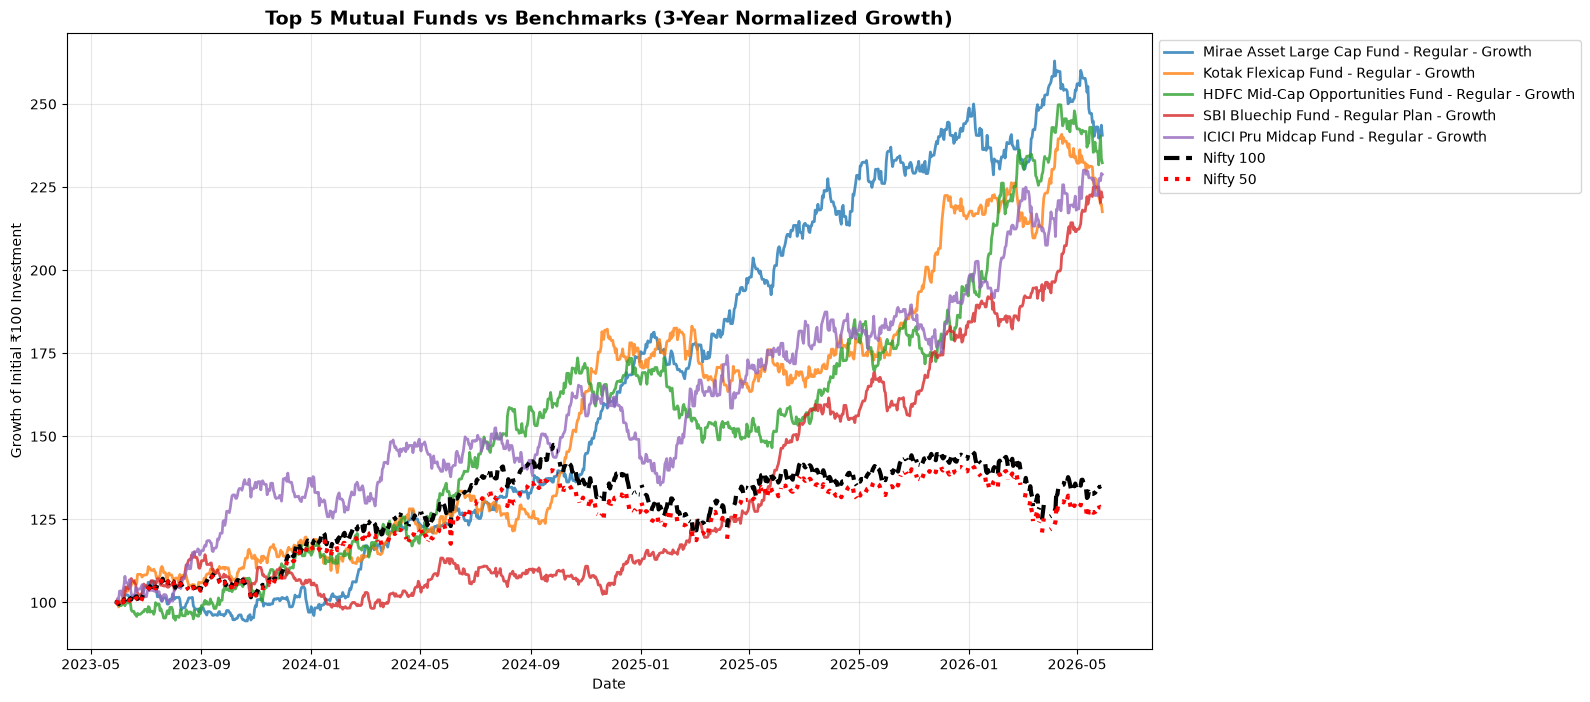


Tracking Error (vs Nifty 50) for Top 5 Funds:


,Scheme,Tracking_Error
0,Mirae Asset Large Cap Fund - Regular - Growth,0.197992
1,Kotak Flexicap Fund - Regular - Growth,0.214118
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.234473
3,SBI Bluechip Fund - Regular Plan - Growth,0.192805
4,ICICI Pru Midcap Fund - Regular - Growth,0.234329


In [10]:
# Fetch Nifty 50 for secondary comparison
nifty50 = yf.download('^NSEI', start=nav_pivot.index.min(), end=nav_pivot.index.max(), progress=False)['Close']

# Safely extract the first columns as Series
nifty100_series = nifty100.iloc[:, 0]
nifty100_series.name = 'Nifty 100'

nifty50_series = nifty50.iloc[:, 0]
nifty50_series.name = 'Nifty 50'

# Identify Top 5 funds from the scorecard
top_5_funds = df_scorecard.head(5).index.tolist()

# Normalize prices to 100 at the start of the 3-year trailing period
three_yrs_ago = nav_pivot.index.max() - pd.DateOffset(years=3)
aligned_prices = pd.concat([nav_pivot[top_5_funds], nifty100_series, nifty50_series], axis=1)
aligned_prices = aligned_prices[aligned_prices.index >= three_yrs_ago].dropna(how='all')

normalized_prices = (aligned_prices / aligned_prices.iloc[0]) * 100

plt.figure(figsize=(14, 8))

# Plot Top 5 Funds
for fund in top_5_funds:
    plt.plot(normalized_prices.index, normalized_prices[fund], label=fund, alpha=0.8, linewidth=2)

# Plot Benchmarks
plt.plot(normalized_prices.index, normalized_prices['Nifty 100'], label='Nifty 100', color='black', linewidth=3, linestyle='--')
plt.plot(normalized_prices.index, normalized_prices['Nifty 50'], label='Nifty 50', color='red', linewidth=3, linestyle=':')

plt.title('Top 5 Mutual Funds vs Benchmarks (3-Year Normalized Growth)', fontsize=14, fontweight='bold')
plt.ylabel('Growth of Initial ₹100 Investment')
plt.xlabel('Date')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True, alpha=0.3)

plt.savefig('../reports/charts/benchmark_comparison.png', bbox_inches='tight', dpi=300)
plt.show()

# Compute Tracking Error vs Nifty 50 for the top 5
te_results = []
nifty50_returns = nifty50_series.pct_change().dropna()
for fund in top_5_funds:
    fund_ret = daily_returns[fund]
    merged = pd.concat([fund_ret, nifty50_returns], axis=1).dropna()
    te = (merged[fund] - merged['Nifty 50']).std() * np.sqrt(252)
    te_results.append({'Scheme': fund, 'Tracking_Error': te})

print("\nTracking Error (vs Nifty 50) for Top 5 Funds:")
display(pd.DataFrame(te_results))